# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Introduction:

The Bank Marketing Prediction project uses machine learning to predict whether a customer will subscribe to a term deposit based on campaign-related information. This helps banks improve the effectiveness of their marketing campaigns and target potential customers more efficiently.


## Problem Statement 

Banks spend significant resources on marketing campaigns, but not all customers subscribe to term deposits. The goal of this project is to develop a classification model that accurately predicts customer subscription, enabling more efficient and cost-effective marketing strategies.

In [1]:
# Import librarries 
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

Loading and exploring the dataset

In [2]:
# Loading dataset
df = pd.read_csv("bank.csv")

In [3]:
# Printing first five rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
print(df.shape)

(11162, 17)


In [5]:
print(df.columns)


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [6]:
print(df.isnull().sum())


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


Encoding all categorical features properly

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

# Print the first 5 rows after encoding
print(df.head())

# Check the data types after encoding
print(df.dtypes)

   age  job  marital  education  default  balance  housing  loan  contact  \
0   59    0        1          1        0     2343        1     0        2   
1   56    0        1          1        0       45        0     0        2   
2   41    9        1          1        0     1270        1     0        2   
3   55    7        1          1        0     2476        1     0        2   
4   54    0        1          2        0      184        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  deposit  
0    5      8      1042         1     -1         0         3        1  
1    5      8      1467         1     -1         0         3        1  
2    5      8      1389         1     -1         0         3        1  
3    5      8       579         1     -1         0         3        1  
4    5      8       673         2     -1         0         3        1  
age          int64
job          int32
marital      int32
education    int32
default      int32
balance   

In [8]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = df.drop("deposit", axis=1)
y = df["deposit"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Train Random Forest model (use unscaled data)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Logistic Regression and Random Forest models trained successfully.")

Logistic Regression and Random Forest models trained successfully.


Logistic Regression Confusion Matrix:
[[   2 1164]
 [   0 1067]]
Logistic Regression F1 Score:
0.6470588235294118


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


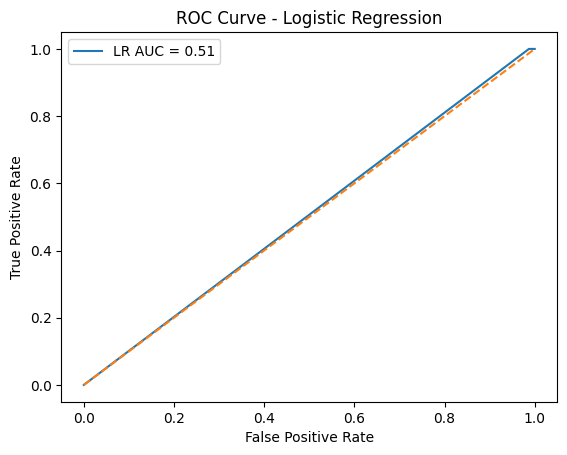


Random Forest Confusion Matrix:
[[952 214]
 [158 909]]
Random Forest F1 Score:
0.8301369863013699


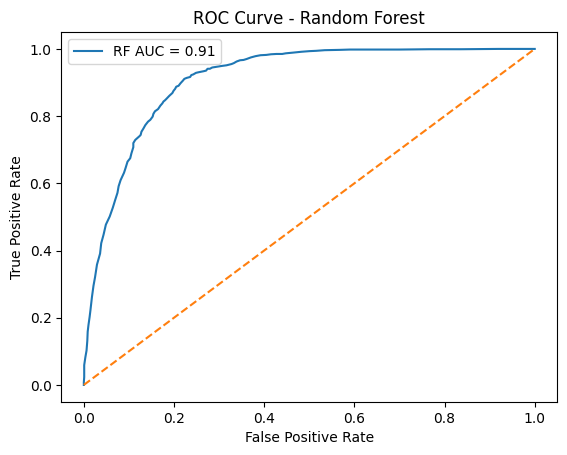

In [9]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# Predictions
lr_pred = lr_model.predict(X_test)

# Confusion Matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

# F1 Score
print("Logistic Regression F1 Score:")
print(f1_score(y_test, lr_pred))

# ROC Curve
lr_prob = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"LR AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# RANDOM FOREST EVALUATION

# Predictions
rf_pred = rf_model.predict(X_test)

# Confusion Matrix
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# F1 Score
print("Random Forest F1 Score:")
print(f1_score(y_test, rf_pred))

# ROC Curve
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"RF AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 99%|===================| 4435/4466 [02:10<00:00]        

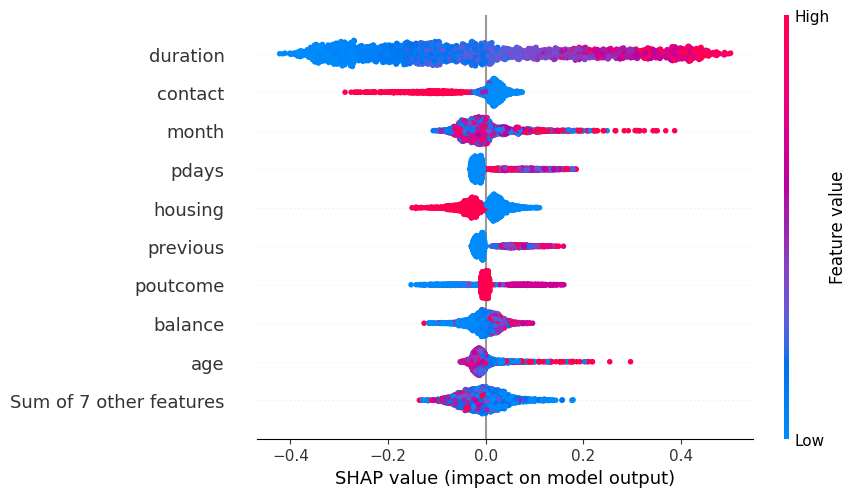

In [10]:
import shap

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test)

# Plot SHAP values for class 1
shap.plots.beeswarm(shap_values[:, :, 1])

Prediction 1
Actual: 0
Predicted: 1


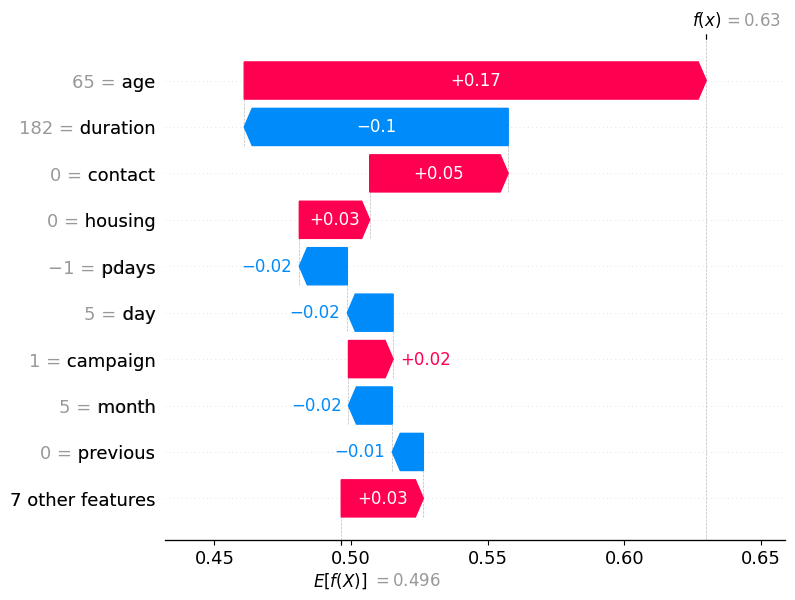

Prediction 2
Actual: 1
Predicted: 1


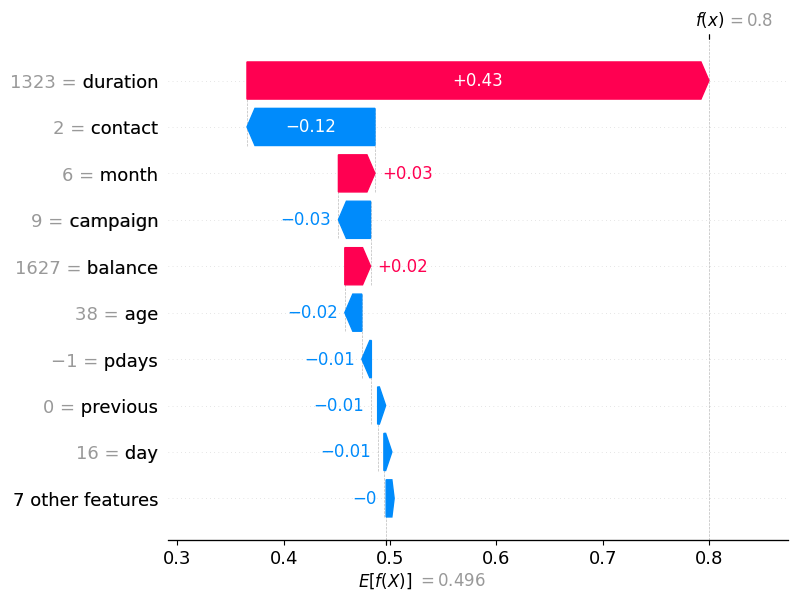

Prediction 3
Actual: 1
Predicted: 1


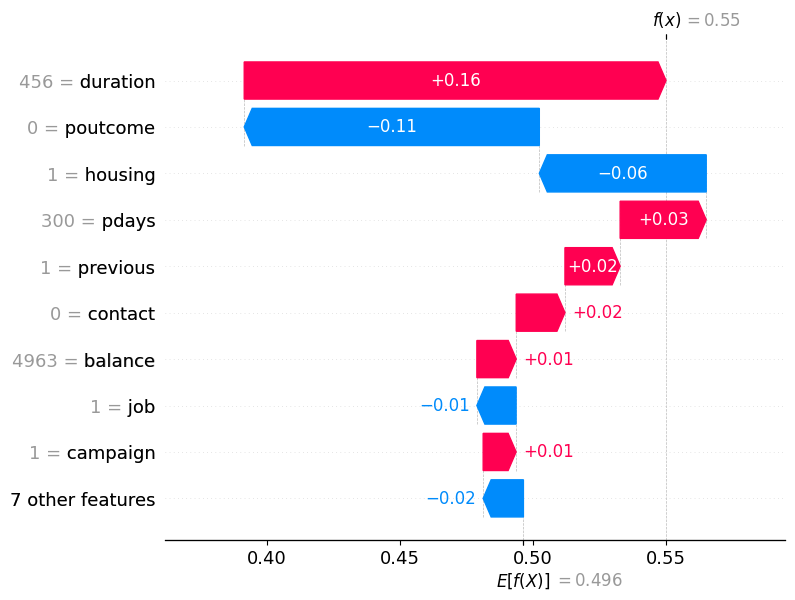

Prediction 4
Actual: 1
Predicted: 1


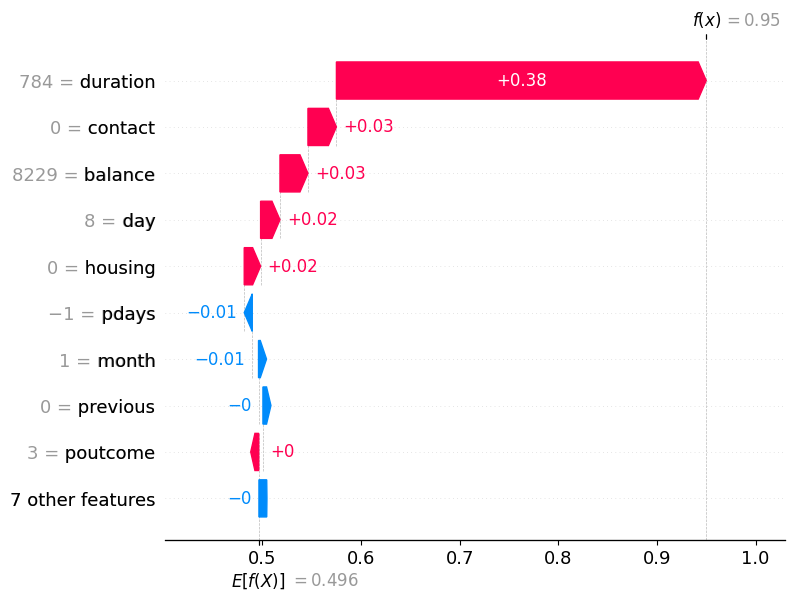

Prediction 5
Actual: 0
Predicted: 0


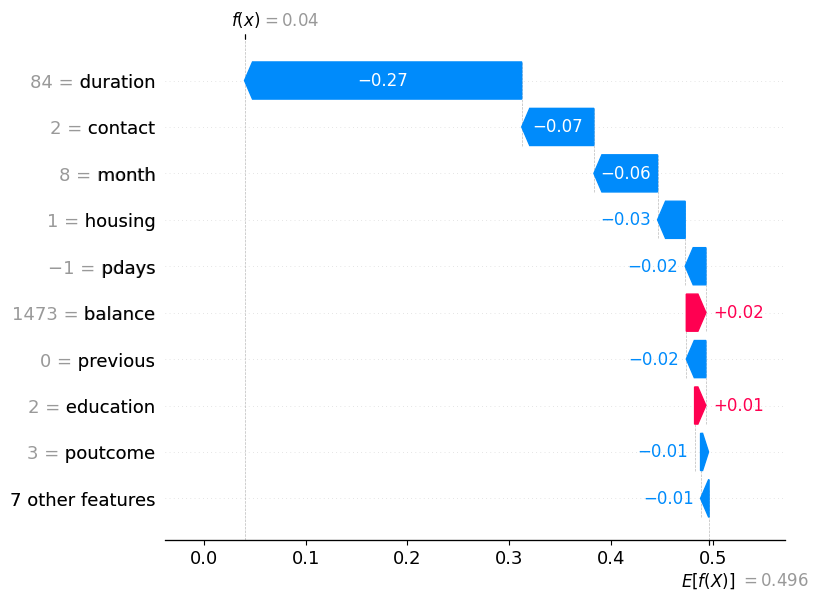

In [11]:
for i in range(5):
    print(f"Prediction {i+1}")
    print("Actual:", y_test.iloc[i])
    print("Predicted:", rf_model.predict(X_test.iloc[[i]])[0])

    shap.plots.waterfall(shap_values[i, :, 1])

## Conclusion

This project successfully built a machine learning model to predict whether a bank customer will subscribe to a term deposit based on marketing data. After preprocessing and encoding categorical features, Logistic Regression and Random Forest models were trained and evaluated using performance metrics such as Confusion Matrix, F1-Score, and ROC Curve. Finally, SHAP was used to interpret individual predictions, making the model transparent by showing how different features influenced each decision.